<a href="https://colab.research.google.com/github/nshanbhag2003/Bigfoot-Bayesian-Analysis/blob/main/Bayesian_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


# Load in Dataset

In [ ]:
import pandas as pd

FILE_PATH = "/content/drive/My Drive/Classes/Spring 2026/GR5224/bfro_locations.csv"

df = pd.read_csv(FILE_PATH)
df.head()

,index,number,title,classification,timestamp,latitude,longitude
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853


# Aggregate to Monthly Counts

=== Full dataset summary ===
Shape: (4250, 9)

Classification counts:
classification
Class B    2138
Class A    2093
Class C      19
Name: count, dtype: int64

Missing values:
number            0
title             0
classification    0
timestamp         0
latitude          0
longitude         0
year              0
month             0
year_month        0
dtype: int64

Head of cleaned sighting-level data:
   number                                              title classification  \
0     637  Report 637: Campers' encounter just after dark...        Class A   
1    2917  Report 2917: Family observes large biped from car        Class A   
2    7963  Report 7963: Sasquatch walks past window of ho...        Class A   
3    9317  Report 9317: Driver on Alcan Highway has noon,...        Class A   
4   13038  Report 13038: Snowmobiler has encounter in dee...        Class A   

                  timestamp  latitude  longitude  year  month year_month  
0 2000-06-16 12:00:00+00:00   61.5000  -142

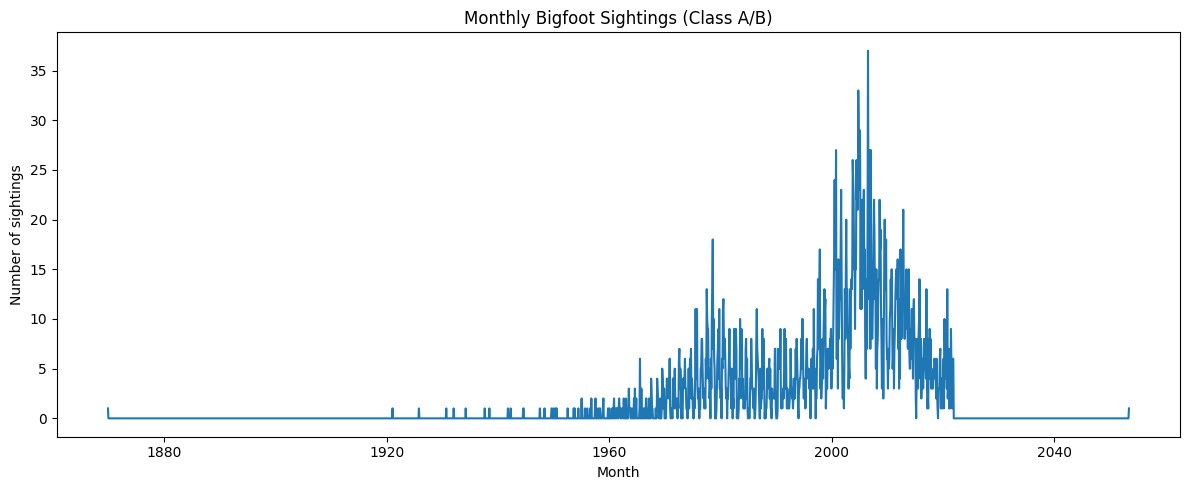

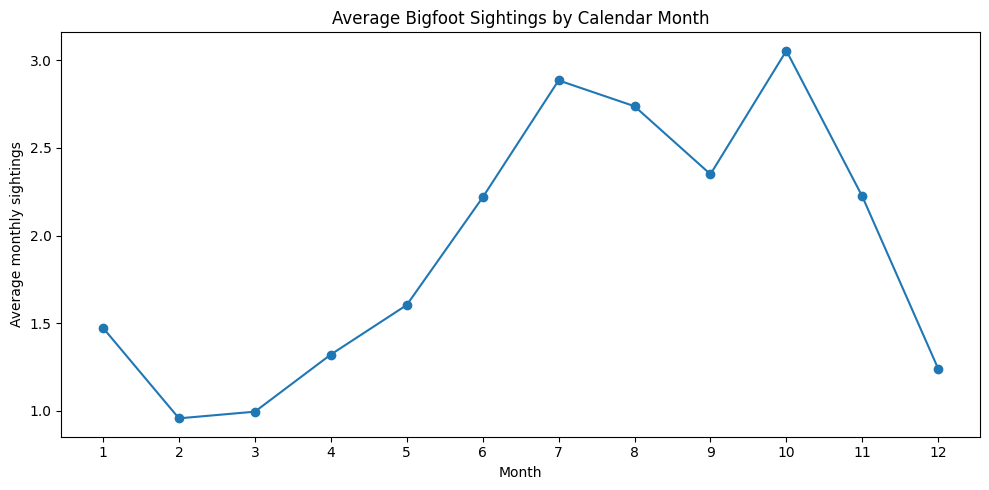

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Load data
# =========================================================
FILE_PATH = "/content/drive/My Drive/Classes/Spring 2026/GR5224/bfro_locations.csv"
df = pd.read_csv(FILE_PATH)

# =========================================================
# 2. Clean and prepare sighting-level data
# =========================================================
bigfoot = df.copy()

# Parse timestamp
bigfoot["timestamp"] = pd.to_datetime(bigfoot["timestamp"], utc=True)

# Keep relevant columns
bigfoot = bigfoot[[
    "number",
    "title",
    "classification",
    "timestamp",
    "latitude",
    "longitude"
]].copy()

# Create time variables
bigfoot["year"] = bigfoot["timestamp"].dt.year
bigfoot["month"] = bigfoot["timestamp"].dt.month
bigfoot["year_month"] = bigfoot["timestamp"].dt.to_period("M").astype(str)

# Basic checks
print("=== Full dataset summary ===")
print("Shape:", bigfoot.shape)
print("\nClassification counts:")
print(bigfoot["classification"].value_counts(dropna=False))
print("\nMissing values:")
print(bigfoot.isna().sum())

print("\nHead of cleaned sighting-level data:")
print(bigfoot.head())

# =========================================================
# 3. Restrict to Class A and Class B
# =========================================================
bigfoot_ab = bigfoot[bigfoot["classification"].isin(["Class A", "Class B"])].copy()

print("\n=== Class A/B subset summary ===")
print("Shape:", bigfoot_ab.shape)
print("\nClassification counts:")
print(bigfoot_ab["classification"].value_counts())

# =========================================================
# 4. Aggregate to monthly counts
# =========================================================
monthly_counts = (
    bigfoot_ab
    .groupby("year_month")
    .size()
    .reset_index(name="sightings")
)

monthly_counts["year_month"] = pd.to_datetime(monthly_counts["year_month"])
monthly_counts = monthly_counts.sort_values("year_month").reset_index(drop=True)

# =========================================================
# 5. Fill in missing months with 0
# =========================================================
monthly_counts = monthly_counts.set_index("year_month")

full_index = pd.date_range(
    start=monthly_counts.index.min(),
    end=monthly_counts.index.max(),
    freq="MS"
)

monthly_counts = (
    monthly_counts
    .reindex(full_index, fill_value=0)
    .rename_axis("year_month")
    .reset_index()
)

monthly_counts["time_index"] = range(len(monthly_counts))
monthly_counts["month"] = monthly_counts["year_month"].dt.month
monthly_counts["year"] = monthly_counts["year_month"].dt.year

# =========================================================
# 6. Summary of monthly series
# =========================================================
print("\n=== Monthly counts summary ===")
print("Date range:", monthly_counts["year_month"].min(), "to", monthly_counts["year_month"].max())
print("\nSightings summary:")
print(monthly_counts["sightings"].describe())

print("\nHead of monthly_counts:")
print(monthly_counts.head())

# =========================================================
# 7. Quick seasonality summary by calendar month
# =========================================================
month_summary = (
    monthly_counts
    .groupby("month")["sightings"]
    .agg(["mean", "median", "sum", "count"])
    .reset_index()
    .sort_values("month")
)

print("\n=== Month-of-year summary ===")
print(month_summary)

# =========================================================
# 8. Plot monthly sightings over time
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(monthly_counts["year_month"], monthly_counts["sightings"])
plt.xlabel("Month")
plt.ylabel("Number of sightings")
plt.title("Monthly Bigfoot Sightings (Class A/B)")
plt.tight_layout()
plt.show()

# =========================================================
# 9. Plot average sightings by month of year
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(month_summary["month"], month_summary["mean"], marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average monthly sightings")
plt.title("Average Bigfoot Sightings by Calendar Month")
plt.tight_layout()
plt.show()

# Data Cleaning

Earliest 15 reports:
      number                                              title  \
213    14338  Report 14338: Old newspaper article (Titusvill...   
1525   14358  Report 14358: Old newspaper article (Clearfiel...   
2963   24413  Report 24413: Woman recounts a tale her Grandf...   
3680    2477  Report 2477: Nine foot tall brown/black creatu...   
3139   24102  Report 24102: Recollections of numerous encoun...   
276    14328  Report 14328: Old newspaper article (Lima, Ohi...   
769    14336  Report 14336: Old newspaper article (The Hammo...   
3676    2395  Report 2395: Sighting at night by a group of c...   
1832    1689  Report 1689: A tall black creature covered wit...   
3464    1303  Report 1303: Sisters observe tall hairy creatu...   
3039   28897  Report 28897: Memory told of a possible daylig...   
171     2896  Report 2896: Sister and brother see 3 creature...   
423     4795  Report 4795: While riding horse, young teen ha...   
1835    1723                  Report 1723

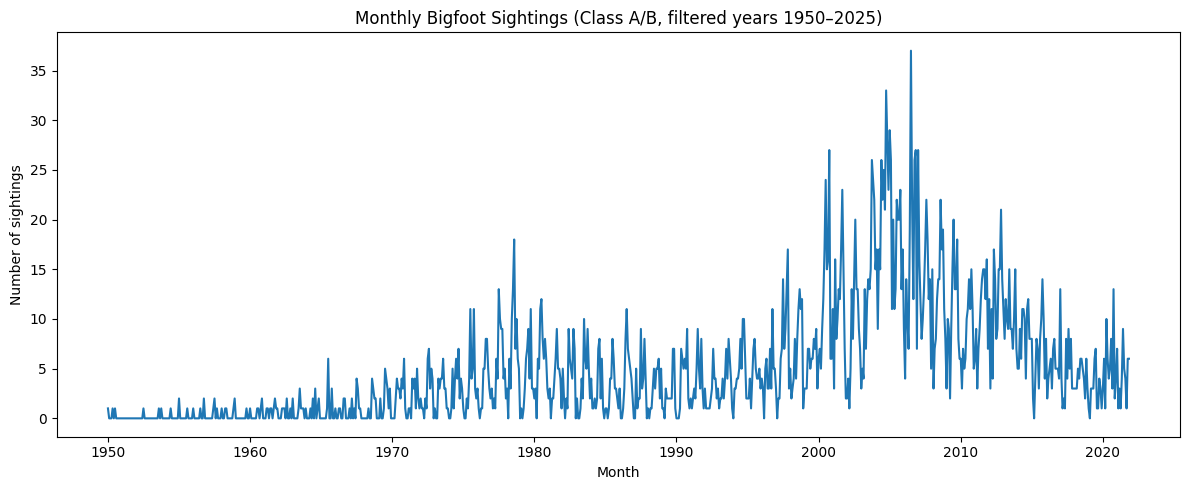

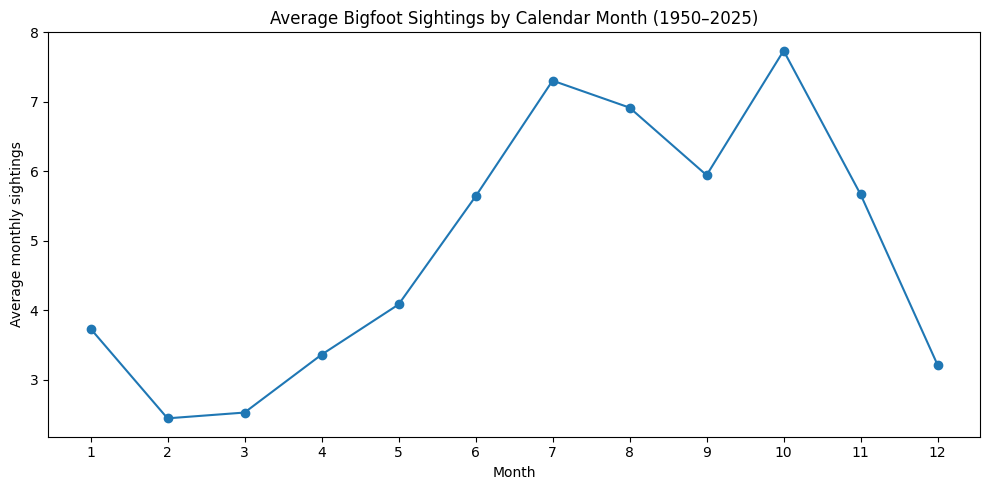

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Inspect suspicious dates
# =========================================================
print("Earliest 15 reports:")
print(
    bigfoot_ab.sort_values("timestamp")[
        ["number", "title", "classification", "timestamp"]
    ].head(15)
)

print("\nLatest 15 reports:")
print(
    bigfoot_ab.sort_values("timestamp")[
        ["number", "title", "classification", "timestamp"]
    ].tail(15)
)

print("\nCounts by year (first 20 years):")
print(bigfoot_ab["year"].value_counts().sort_index().head(20))

print("\nCounts by year (last 20 years):")
print(bigfoot_ab["year"].value_counts().sort_index().tail(20))

# =========================================================
# 2. Restrict to a plausible analysis window
# =========================================================
bigfoot_model = bigfoot_ab[
    (bigfoot_ab["year"] >= 1950) &
    (bigfoot_ab["year"] <= 2025)
].copy()

print("\n=== Filtered analysis sample ===")
print("Shape:", bigfoot_model.shape)
print("Date range:", bigfoot_model["timestamp"].min(), "to", bigfoot_model["timestamp"].max())

# =========================================================
# 3. Rebuild monthly counts on filtered sample
# =========================================================
monthly_counts = (
    bigfoot_model
    .groupby("year_month")
    .size()
    .reset_index(name="sightings")
)

monthly_counts["year_month"] = pd.to_datetime(monthly_counts["year_month"])
monthly_counts = monthly_counts.sort_values("year_month").reset_index(drop=True)

monthly_counts = monthly_counts.set_index("year_month")

full_index = pd.date_range(
    start=monthly_counts.index.min(),
    end=monthly_counts.index.max(),
    freq="MS"
)

monthly_counts = (
    monthly_counts
    .reindex(full_index, fill_value=0)
    .rename_axis("year_month")
    .reset_index()
)

monthly_counts["time_index"] = range(len(monthly_counts))
monthly_counts["month"] = monthly_counts["year_month"].dt.month
monthly_counts["year"] = monthly_counts["year_month"].dt.year

# =========================================================
# 4. Summaries after filtering
# =========================================================
print("\n=== Monthly counts after filtering ===")
print(monthly_counts["sightings"].describe())
print("Date range:", monthly_counts["year_month"].min(), "to", monthly_counts["year_month"].max())

month_summary = (
    monthly_counts
    .groupby("month")["sightings"]
    .agg(["mean", "median", "sum", "count"])
    .reset_index()
    .sort_values("month")
)

print("\n=== Month-of-year summary after filtering ===")
print(month_summary)

# =========================================================
# 5. Plot cleaned monthly series
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(monthly_counts["year_month"], monthly_counts["sightings"])
plt.xlabel("Month")
plt.ylabel("Number of sightings")
plt.title("Monthly Bigfoot Sightings (Class A/B, filtered years 1950–2025)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(month_summary["month"], month_summary["mean"], marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average monthly sightings")
plt.title("Average Bigfoot Sightings by Calendar Month (1950–2025)")
plt.tight_layout()
plt.show()

# EDA

=== Overdispersion check ===
Mean of monthly sightings     : 4.883
Variance of monthly sightings : 32.892
Variance / Mean               : 6.736

=== Annual totals summary ===
   year  sightings
0  1950          3
1  1951          0
2  1952          1
3  1953          2
4  1954          1
    year  sightings
67  2017         61
68  2018         50
69  2019         33
70  2020         65
71  2021         47


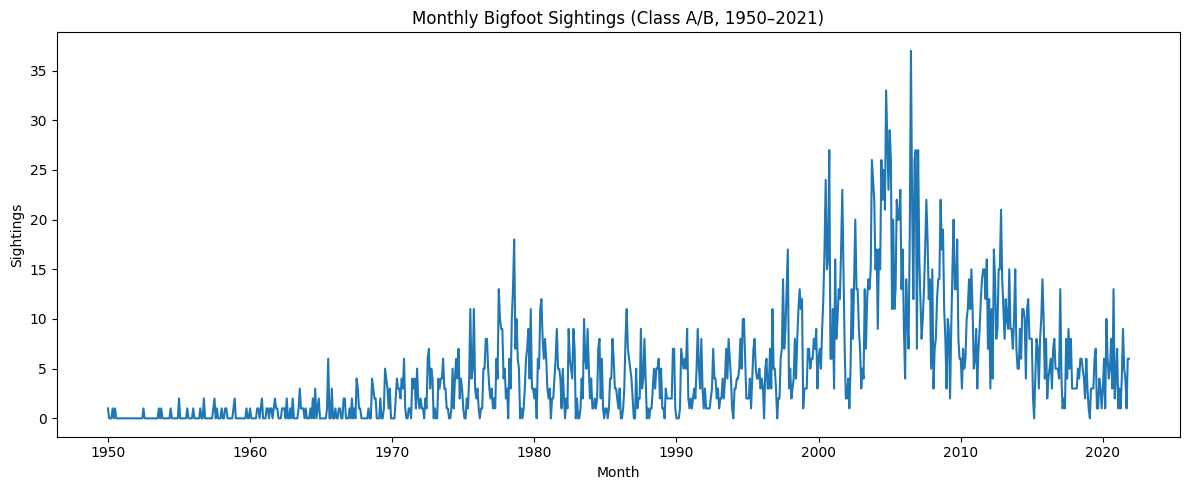

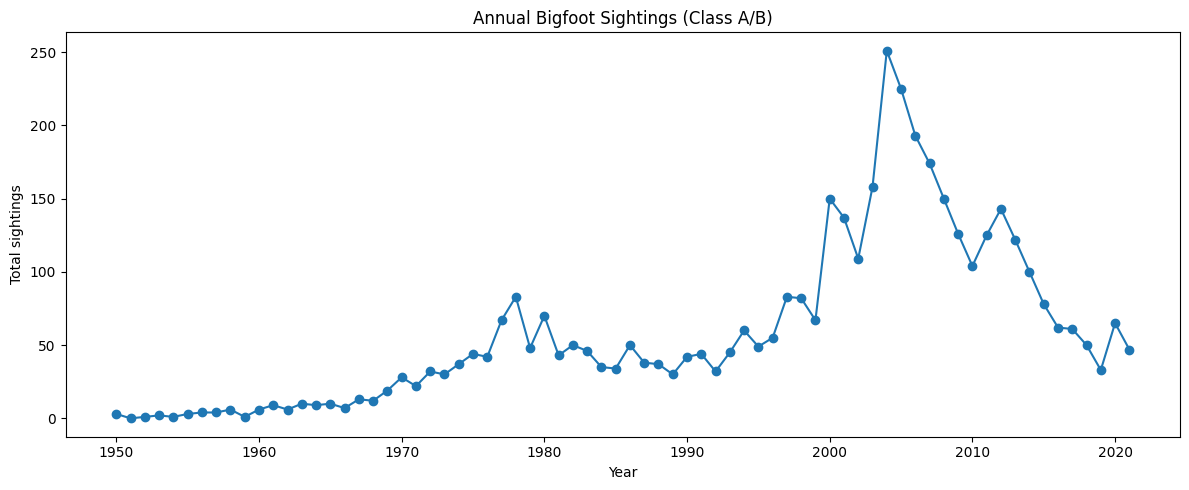

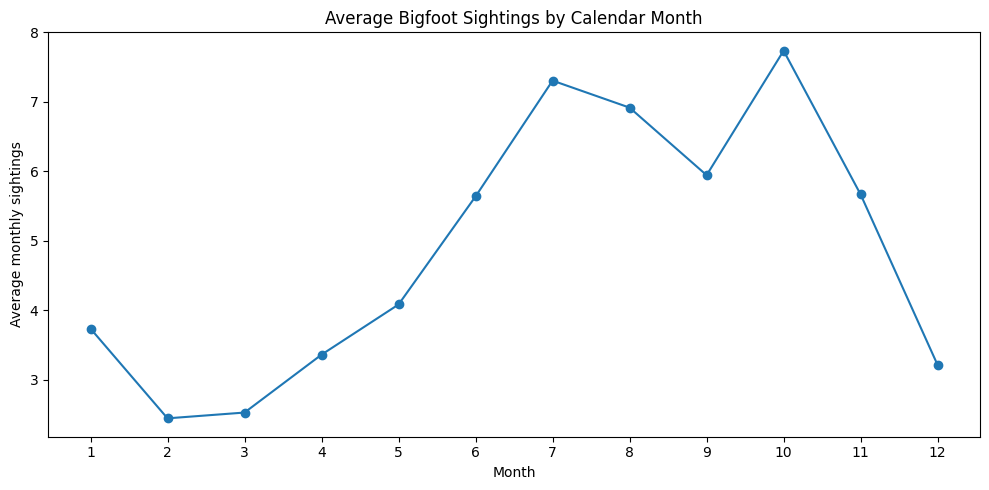

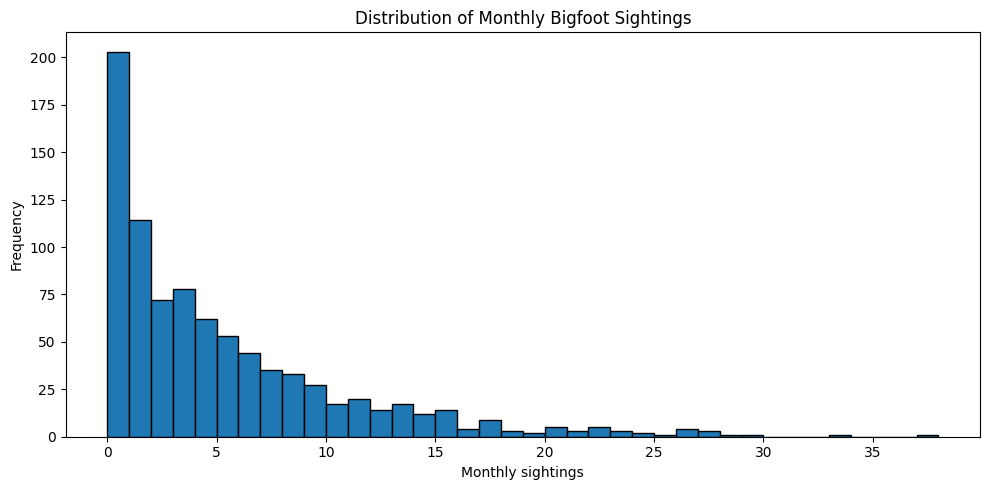

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Assume monthly_counts already exists from your cleaned step
# ---------------------------------------------------------

model_df = monthly_counts.copy()

# Month index for modeling (0,...,11)
model_df["month_idx"] = model_df["month"] - 1

# Standardized time trend for better priors / MCMC stability
model_df["time_std"] = (
    model_df["time_index"] - model_df["time_index"].mean()
) / model_df["time_index"].std()

# Optional centered year variable
model_df["year_centered"] = model_df["year"] - model_df["year"].mean()

# ---------------------------------------------------------
# 1. Check overdispersion
# ---------------------------------------------------------
mean_y = model_df["sightings"].mean()
var_y = model_df["sightings"].var()

print("=== Overdispersion check ===")
print(f"Mean of monthly sightings     : {mean_y:.3f}")
print(f"Variance of monthly sightings : {var_y:.3f}")
print(f"Variance / Mean               : {var_y / mean_y:.3f}")

# ---------------------------------------------------------
# 2. Annual totals
# ---------------------------------------------------------
annual_counts = (
    model_df.groupby("year")["sightings"]
    .sum()
    .reset_index()
)

print("\n=== Annual totals summary ===")
print(annual_counts.head())
print(annual_counts.tail())

# ---------------------------------------------------------
# 3. Plot monthly time series
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(model_df["year_month"], model_df["sightings"])
plt.xlabel("Month")
plt.ylabel("Sightings")
plt.title("Monthly Bigfoot Sightings (Class A/B, 1950–2021)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Plot annual totals
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(annual_counts["year"], annual_counts["sightings"], marker="o")
plt.xlabel("Year")
plt.ylabel("Total sightings")
plt.title("Annual Bigfoot Sightings (Class A/B)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Plot average sightings by month of year
# ---------------------------------------------------------
month_summary = (
    model_df.groupby("month")["sightings"]
    .agg(["mean", "median", "sum", "count"])
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(month_summary["month"], month_summary["mean"], marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average monthly sightings")
plt.title("Average Bigfoot Sightings by Calendar Month")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. Distribution of counts
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(model_df["sightings"], bins=range(0, model_df["sightings"].max() + 2), edgecolor="black")
plt.xlabel("Monthly sightings")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Bigfoot Sightings")
plt.tight_layout()
plt.show()

# Fit Poisson + NB Regression

## First Set of Priors

  year_month  sightings  time_index  month  year  month_idx  time_std  \
0 1950-01-01          1           0      1  1950          0 -1.729042   
1 1950-02-01          0           1      2  1950          1 -1.725031   
2 1950-03-01          0           2      3  1950          2 -1.721019   
3 1950-04-01          0           3      4  1950          3 -1.717007   
4 1950-05-01          1           4      5  1950          4 -1.712996   

   year_centered  time_std_sq  
0     -35.458864     2.989587  
1     -35.458864     2.975731  
2     -35.458864     2.961906  
3     -35.458864     2.948114  
4     -35.458864     2.934354  

Columns:
['year_month', 'sightings', 'time_index', 'month', 'year', 'month_idx', 'time_std', 'year_centered', 'time_std_sq']

Sightings summary:
count    863.000000
mean       4.882966
std        5.735183
min        0.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       37.000000
Name: sightings, dtype: float64

n_obs = 863
Unique month_idx v

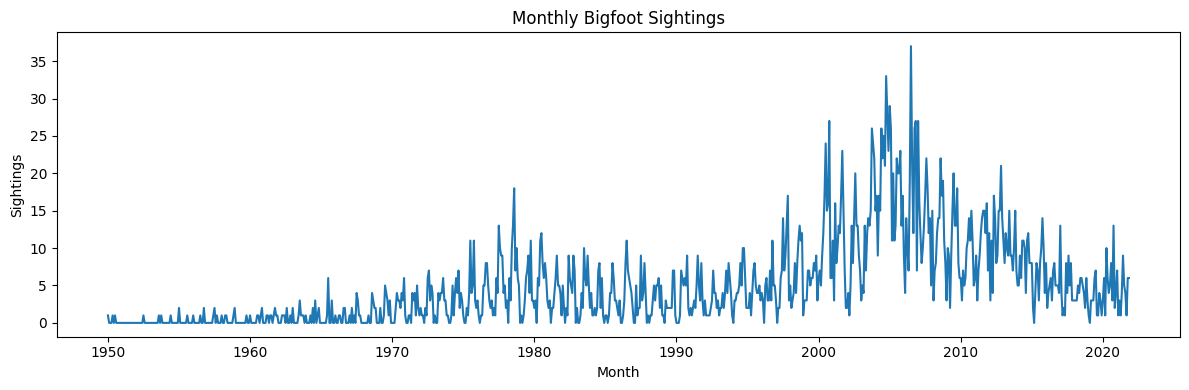

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm
import pytensor.tensor as pt

# ---------------------------------------------------------
# 1. Make sure model_df has the variables we need
# ---------------------------------------------------------
if "time_std_sq" not in model_df.columns:
    model_df["time_std_sq"] = model_df["time_std"] ** 2

# ---------------------------------------------------------
# 2. Extract arrays for PyMC
# ---------------------------------------------------------
y = model_df["sightings"].to_numpy().astype("int64")
time_std = model_df["time_std"].to_numpy().astype("float64")
time_std_sq = model_df["time_std_sq"].to_numpy().astype("float64")
month_idx = model_df["month_idx"].to_numpy().astype("int64")

n_obs = len(model_df)
n_months = 12

coords = {
    "obs_id": np.arange(n_obs),
    "month": np.arange(1, 13),
}

# ---------------------------------------------------------
# 3. Sanity checks
# ---------------------------------------------------------
print(model_df.head())
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSightings summary:")
print(model_df["sightings"].describe())

print("\nn_obs =", n_obs)
print("Unique month_idx values =", np.unique(month_idx))

# ---------------------------------------------------------
# 4. Quick plot of the time series
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(model_df["year_month"], y)
plt.xlabel("Month")
plt.ylabel("Sightings")
plt.title("Monthly Bigfoot Sightings")
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Poisson model: month effects + linear time trend
# ---------------------------------------------------------
with pm.Model(coords=coords) as poisson_model:
    # Data containers
    y_data = pm.Data("y_data", y, dims="obs_id")
    t_data = pm.Data("t_data", time_std, dims="obs_id")
    m_data = pm.Data("m_data", month_idx, dims="obs_id")

    # Priors
    alpha = pm.Normal("alpha", mu=0.0, sigma=3.0)
    beta_time = pm.Normal("beta_time", mu=0.0, sigma=1.0)

    # Sum-to-zero month effects
    month_raw = pm.Normal("month_raw", mu=0.0, sigma=1.0, dims="month")
    month_eff = pm.Deterministic(
        "month_eff",
        month_raw - pt.mean(month_raw),
        dims="month"
    )

    # Linear predictor and mean
    eta = alpha + beta_time * t_data + month_eff[m_data]
    mu = pm.Deterministic("mu", pt.exp(eta), dims="obs_id")

    # Likelihood
    y_obs = pm.Poisson("y_obs", mu=mu, observed=y_data, dims="obs_id")

    # Sample posterior
    idata_pois = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

print(
    az.summary(
        idata_pois,
        var_names=["alpha", "beta_time", "month_eff"],
        round_to=3
    )
)

Output()

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha          1.256  0.021   1.219    1.297      0.000    0.000   2107.790   
beta_time      0.732  0.018   0.699    0.766      0.000    0.000   2468.823   
month_eff[1]  -0.180  0.059  -0.288   -0.068      0.001    0.001  10721.495   
month_eff[2]  -0.605  0.070  -0.741   -0.480      0.001    0.001  10138.518   
month_eff[3]  -0.575  0.070  -0.703   -0.440      0.001    0.001   9433.188   
month_eff[4]  -0.292  0.061  -0.407   -0.180      0.001    0.001  11480.664   
month_eff[5]  -0.102  0.056  -0.209   -0.000      0.001    0.001  11989.965   
month_eff[6]   0.217  0.047   0.132    0.309      0.000    0.001  12281.117   
month_eff[7]   0.473  0.044   0.391    0.555      0.000    0.001  10923.623   
month_eff[8]   0.415  0.045   0.331    0.500      0.000    0.001  11865.853   
month_eff[9]   0.261  0.048   0.167    0.349      0.000    0.001  14240.274   
month_eff[10]  0.522  0.042   0.445    0.602      0.

In [ ]:
# ---------------------------------------------------------
# Negative Binomial model: month effects + linear time trend
# ---------------------------------------------------------
with pm.Model(coords=coords) as nb_model:
    # Data containers
    y_data = pm.Data("y_data", y, dims="obs_id")
    t_data = pm.Data("t_data", time_std, dims="obs_id")
    m_data = pm.Data("m_data", month_idx, dims="obs_id")

    # Priors
    alpha = pm.Normal("alpha", mu=0.0, sigma=3.0)
    beta_time = pm.Normal("beta_time", mu=0.0, sigma=1.0)

    # Sum-to-zero month effects
    month_raw = pm.Normal("month_raw", mu=0.0, sigma=1.0, dims="month")
    month_eff = pm.Deterministic(
        "month_eff",
        month_raw - pt.mean(month_raw),
        dims="month"
    )

    # Overdispersion parameter
    alpha_nb = pm.Exponential("alpha_nb", lam=1.0)

    # Linear predictor and mean
    eta = alpha + beta_time * t_data + month_eff[m_data]
    mu = pm.Deterministic("mu", pt.exp(eta), dims="obs_id")

    # Likelihood
    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu,
        alpha=alpha_nb,
        observed=y_data,
        dims="obs_id"
    )

    # Sample posterior
    idata_nb = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

print(
    az.summary(
        idata_nb,
        var_names=["alpha", "beta_time", "alpha_nb", "month_eff"],
        round_to=3
    )
)

Output()

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha          1.142  0.033   1.081    1.208      0.001    0.000   3813.319   
beta_time      0.995  0.038   0.925    1.069      0.001    0.000   3887.574   
alpha_nb       2.207  0.176   1.889    2.541      0.003    0.002   4071.933   
month_eff[1]  -0.258  0.103  -0.456   -0.068      0.001    0.001  15244.533   
month_eff[2]  -0.709  0.116  -0.935   -0.494      0.001    0.001  13627.017   
month_eff[3]  -0.685  0.111  -0.893   -0.477      0.001    0.001  14579.409   
month_eff[4]  -0.304  0.105  -0.508   -0.112      0.001    0.001  15396.390   
month_eff[5]  -0.123  0.101  -0.303    0.076      0.001    0.001  15102.873   
month_eff[6]   0.243  0.098   0.061    0.430      0.001    0.001  17820.445   
month_eff[7]   0.611  0.093   0.440    0.789      0.001    0.001  14322.241   
month_eff[8]   0.529  0.095   0.347    0.702      0.001    0.001  15980.755   
month_eff[9]   0.308  0.094   0.129    0.481      0.

In [ ]:
# ---------------------------------------------------------
# Negative Binomial model: month effects + linear + quadratic time trend
# ---------------------------------------------------------
with pm.Model(coords=coords) as nb_quad_model:
    y_data = pm.Data("y_data", y, dims="obs_id")
    t_data = pm.Data("t_data", time_std, dims="obs_id")
    t2_data = pm.Data("t2_data", time_std_sq, dims="obs_id")
    m_data = pm.Data("m_data", month_idx, dims="obs_id")

    alpha = pm.Normal("alpha", mu=0.0, sigma=3.0)
    beta_time = pm.Normal("beta_time", mu=0.0, sigma=1.0)
    beta_time_sq = pm.Normal("beta_time_sq", mu=0.0, sigma=1.0)

    month_raw = pm.Normal("month_raw", mu=0.0, sigma=1.0, dims="month")
    month_eff = pm.Deterministic(
        "month_eff",
        month_raw - pt.mean(month_raw),
        dims="month"
    )

    alpha_nb = pm.Exponential("alpha_nb", lam=1.0)

    eta = alpha + beta_time * t_data + beta_time_sq * t2_data + month_eff[m_data]
    mu = pm.Deterministic("mu", pt.exp(eta), dims="obs_id")

    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu,
        alpha=alpha_nb,
        observed=y_data,
        dims="obs_id"
    )

    idata_nb_quad = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

print(
    az.summary(
        idata_nb_quad,
        var_names=["alpha", "beta_time", "beta_time_sq", "alpha_nb", "month_eff"],
        round_to=3
    )
)

Output()

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha          1.565  0.041   1.489    1.640      0.001    0.001   3392.158   
beta_time      1.205  0.041   1.127    1.282      0.001    0.001   3558.714   
beta_time_sq  -0.611  0.042  -0.686   -0.527      0.001    0.001   2909.443   
alpha_nb       3.382  0.312   2.814    3.969      0.005    0.004   4335.007   
month_eff[1]  -0.215  0.094  -0.387   -0.039      0.001    0.001  12919.828   
month_eff[2]  -0.680  0.100  -0.861   -0.483      0.001    0.001  13357.123   
month_eff[3]  -0.643  0.099  -0.826   -0.463      0.001    0.001  13640.833   
month_eff[4]  -0.302  0.093  -0.476   -0.127      0.001    0.001  13753.216   
month_eff[5]  -0.121  0.090  -0.294    0.044      0.001    0.001  12906.405   
month_eff[6]   0.237  0.089   0.074    0.406      0.001    0.001  14903.324   
month_eff[7]   0.571  0.084   0.411    0.726      0.001    0.001  11928.230   
month_eff[8]   0.497  0.084   0.343    0.660      0.

## Second Set of Priors

In [ ]:
# ---------------------------------------------------------
# Poisson model, second set of priors:
# stronger shrinkage
# ---------------------------------------------------------
with pm.Model(coords=coords) as poisson_model_prior2:
    # Data containers
    y_data = pm.Data("y_data", y, dims="obs_id")
    t_data = pm.Data("t_data", time_std, dims="obs_id")
    m_data = pm.Data("m_data", month_idx, dims="obs_id")

    # Prior Set B
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)
    beta_time = pm.Normal("beta_time", mu=0.0, sigma=0.5)

    # Sum-to-zero month effects
    month_raw = pm.Normal("month_raw", mu=0.0, sigma=0.5, dims="month")
    month_eff = pm.Deterministic(
        "month_eff",
        month_raw - pt.mean(month_raw),
        dims="month"
    )

    # Linear predictor and mean
    eta = alpha + beta_time * t_data + month_eff[m_data]
    mu = pm.Deterministic("mu", pt.exp(eta), dims="obs_id")

    # Likelihood
    y_obs = pm.Poisson("y_obs", mu=mu, observed=y_data, dims="obs_id")

    # Sample posterior
    idata_pois_prior2 = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

print(
    az.summary(
        idata_pois_prior2,
        var_names=["alpha", "beta_time", "month_eff"],
        round_to=3
    )
)

pois_prior_compare = pd.concat(
    [
        az.summary(idata_pois, var_names=["alpha", "beta_time"], round_to=3).assign(prior="Set A"),
        az.summary(idata_pois_prior2, var_names=["alpha", "beta_time"], round_to=3).assign(prior="Set B"),
    ]
)

print(pois_prior_compare)

Output()

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha          1.257  0.020   1.219    1.296      0.000    0.000   3341.646   
beta_time      0.732  0.018   0.698    0.765      0.000    0.000   3589.618   
month_eff[1]  -0.180  0.058  -0.290   -0.070      0.001    0.001  13210.759   
month_eff[2]  -0.597  0.069  -0.730   -0.471      0.001    0.001   9965.264   
month_eff[3]  -0.566  0.069  -0.694   -0.439      0.001    0.001   9927.258   
month_eff[4]  -0.292  0.060  -0.407   -0.180      0.001    0.001  12611.009   
month_eff[5]  -0.103  0.055  -0.205    0.004      0.001    0.001  11778.005   
month_eff[6]   0.214  0.048   0.123    0.302      0.000    0.001  14928.957   
month_eff[7]   0.469  0.043   0.389    0.548      0.000    0.001  14345.900   
month_eff[8]   0.411  0.045   0.325    0.493      0.000    0.001  14190.177   
month_eff[9]   0.257  0.047   0.171    0.345      0.000    0.001  15223.296   
month_eff[10]  0.517  0.042   0.438    0.594      0.

In [ ]:
# ---------------------------------------------------------
# Negative Binomial model, second set of priors:
# stronger shrinkage
# ---------------------------------------------------------
with pm.Model(coords=coords) as nb_model_prior2:
    # Data containers
    y_data = pm.Data("y_data", y, dims="obs_id")
    t_data = pm.Data("t_data", time_std, dims="obs_id")
    m_data = pm.Data("m_data", month_idx, dims="obs_id")

    # Prior Set B
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)
    beta_time = pm.Normal("beta_time", mu=0.0, sigma=0.5)

    # Sum-to-zero month effects
    month_raw = pm.Normal("month_raw", mu=0.0, sigma=0.5, dims="month")
    month_eff = pm.Deterministic(
        "month_eff",
        month_raw - pt.mean(month_raw),
        dims="month"
    )

    # Overdispersion prior
    alpha_nb = pm.Exponential("alpha_nb", lam=0.5)

    # Linear predictor and mean
    eta = alpha + beta_time * t_data + month_eff[m_data]
    mu = pm.Deterministic("mu", pt.exp(eta), dims="obs_id")

    # Likelihood
    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu,
        alpha=alpha_nb,
        observed=y_data,
        dims="obs_id"
    )

    # Sample posterior
    idata_nb_prior2 = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

print(
    az.summary(
        idata_nb_prior2,
        var_names=["alpha", "beta_time", "alpha_nb", "month_eff"],
        round_to=3
    )
)

nb_prior_compare = pd.concat(
    [
        az.summary(idata_nb, var_names=["alpha", "beta_time", "alpha_nb"], round_to=3).assign(prior="Set A"),
        az.summary(idata_nb_prior2, var_names=["alpha", "beta_time", "alpha_nb"], round_to=3).assign(prior="Set B"),
    ]
)

print(nb_prior_compare)

Output()

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha          1.146  0.033   1.087    1.211      0.000    0.000   5586.878   
beta_time      0.987  0.037   0.917    1.054      0.000    0.000   6497.995   
alpha_nb       2.230  0.175   1.897    2.548      0.002    0.002   7241.658   
month_eff[1]  -0.250  0.102  -0.442   -0.063      0.001    0.001  18489.616   
month_eff[2]  -0.681  0.112  -0.896   -0.472      0.001    0.001  19597.457   
month_eff[3]  -0.658  0.110  -0.875   -0.461      0.001    0.002  15885.471   
month_eff[4]  -0.297  0.101  -0.484   -0.103      0.001    0.001  15401.215   
month_eff[5]  -0.121  0.099  -0.311    0.060      0.001    0.001  16800.972   
month_eff[6]   0.233  0.097   0.054    0.419      0.001    0.001  18935.694   
month_eff[7]   0.590  0.092   0.414    0.757      0.001    0.001  15622.279   
month_eff[8]   0.510  0.094   0.339    0.689      0.001    0.001  18726.628   
month_eff[9]   0.297  0.092   0.122    0.471      0.

In [ ]:
# ---------------------------------------------------------
# Negative Binomial quadratic model, second set of priors:
# stronger shrinkage priors
# ---------------------------------------------------------
with pm.Model(coords=coords) as nb_quad_model_prior2:
    # Data containers
    y_data = pm.Data("y_data", y, dims="obs_id")
    t_data = pm.Data("t_data", time_std, dims="obs_id")
    t2_data = pm.Data("t2_data", time_std_sq, dims="obs_id")
    m_data = pm.Data("m_data", month_idx, dims="obs_id")

    # Prior Set B
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)
    beta_time = pm.Normal("beta_time", mu=0.0, sigma=0.5)
    beta_time_sq = pm.Normal("beta_time_sq", mu=0.0, sigma=0.5)

    # Sum-to-zero month effects
    month_raw = pm.Normal("month_raw", mu=0.0, sigma=0.5, dims="month")
    month_eff = pm.Deterministic(
        "month_eff",
        month_raw - pt.mean(month_raw),
        dims="month"
    )

    # Overdispersion prior
    alpha_nb = pm.Exponential("alpha_nb", lam=0.5)

    # Linear predictor
    eta = alpha + beta_time * t_data + beta_time_sq * t2_data + month_eff[m_data]
    mu = pm.Deterministic("mu", pt.exp(eta), dims="obs_id")

    # Likelihood
    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu,
        alpha=alpha_nb,
        observed=y_data,
        dims="obs_id"
    )

    # Sample posterior
    idata_nb_quad_prior2 = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

print(
    az.summary(
        idata_nb_quad_prior2,
        var_names=["alpha", "beta_time", "beta_time_sq", "alpha_nb", "month_eff"],
        round_to=3
    )
)

nb_quad_prior_compare = pd.concat(
    [
        az.summary(
            idata_nb_quad,
            var_names=["alpha", "beta_time", "beta_time_sq", "alpha_nb"],
            round_to=3
        ).assign(prior="Set A"),
        az.summary(
            idata_nb_quad_prior2,
            var_names=["alpha", "beta_time", "beta_time_sq", "alpha_nb"],
            round_to=3
        ).assign(prior="Set B"),
    ]
)

print(nb_quad_prior_compare)

Output()

                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha          1.567  0.040   1.492    1.640      0.001    0.000   4334.314   
beta_time      1.195  0.042   1.118    1.275      0.001    0.000   4439.201   
beta_time_sq  -0.607  0.042  -0.686   -0.530      0.001    0.000   3698.971   
alpha_nb       3.446  0.328   2.837    4.058      0.004    0.004   5543.414   
month_eff[1]  -0.211  0.090  -0.381   -0.043      0.001    0.001  13599.062   
month_eff[2]  -0.658  0.098  -0.844   -0.481      0.001    0.001  11184.901   
month_eff[3]  -0.621  0.100  -0.805   -0.431      0.001    0.001  11419.163   
month_eff[4]  -0.295  0.091  -0.471   -0.127      0.001    0.001  14227.710   
month_eff[5]  -0.120  0.087  -0.281    0.046      0.001    0.001  14967.481   
month_eff[6]   0.230  0.085   0.070    0.391      0.001    0.001  15409.029   
month_eff[7]   0.555  0.083   0.405    0.714      0.001    0.001  15329.215   
month_eff[8]   0.483  0.083   0.326    0.640      0.

# Comparison of Fitted Models

In [ ]:
comparison_df = az.compare(
    {
        "Poisson": idata_pois,
        "NegBin_linear": idata_nb,
        "NegBin_quadratic": idata_nb_quad,
    },
    ic="loo"
)

print(comparison_df)

                  rank     elpd_loo      p_loo   elpd_diff    weight  \
NegBin_quadratic     0 -1857.648806  16.321992    0.000000  0.990791   
NegBin_linear        1 -1961.469457  14.831470  103.820651  0.000000   
Poisson              2 -2473.794453  58.269317  616.145647  0.009209   

                         se        dse  warning scale  
NegBin_quadratic  37.191668   0.000000    False   log  
NegBin_linear     37.375593  12.373625    False   log  
Poisson           88.240874  65.195914    False   log  


# Graphs of Final Fitted Model

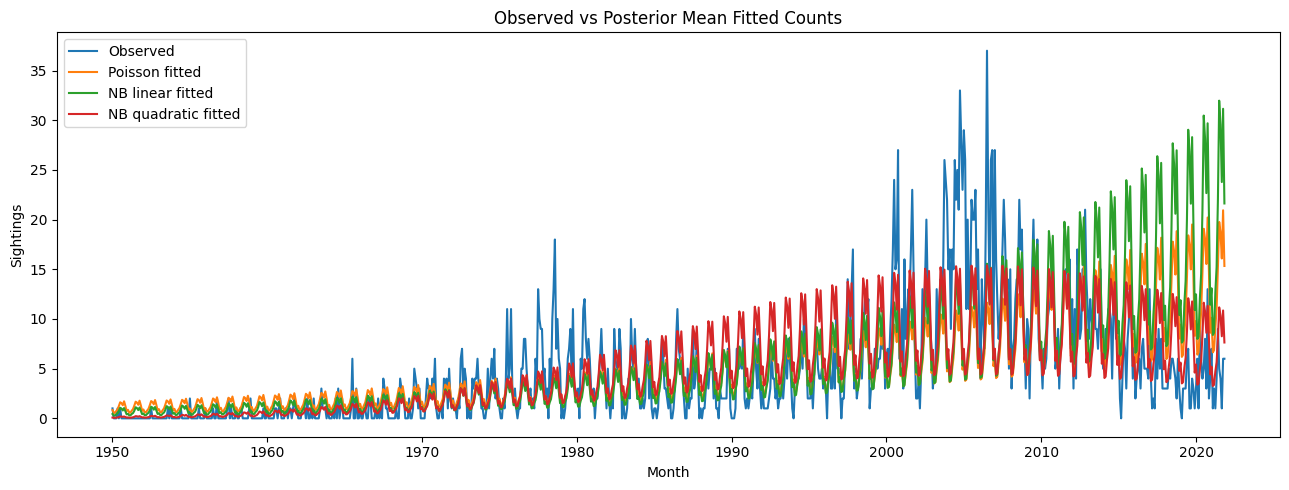

In [ ]:
def posterior_mean_mu(idata):
    return idata.posterior["mu"].mean(dim=("chain", "draw")).values

mu_pois = posterior_mean_mu(idata_pois)
mu_nb = posterior_mean_mu(idata_nb)
mu_nb_quad = posterior_mean_mu(idata_nb_quad)

plt.figure(figsize=(13, 5))
plt.plot(model_df["year_month"], y, label="Observed")
plt.plot(model_df["year_month"], mu_pois, label="Poisson fitted")
plt.plot(model_df["year_month"], mu_nb, label="NB linear fitted")
plt.plot(model_df["year_month"], mu_nb_quad, label="NB quadratic fitted")
plt.xlabel("Month")
plt.ylabel("Sightings")
plt.title("Observed vs Posterior Mean Fitted Counts")
plt.legend()
plt.tight_layout()
plt.show()

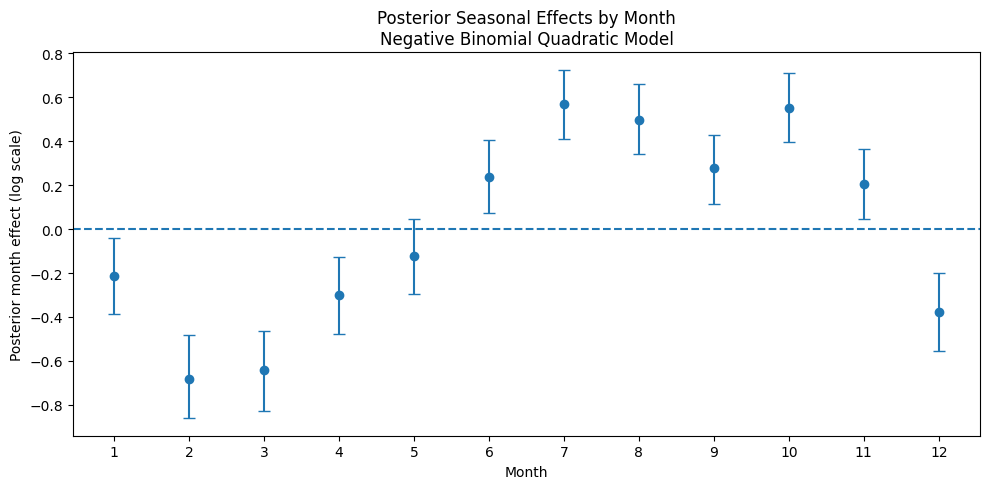

    month   mean  hdi_3%  hdi_97%
0       1 -0.215  -0.387   -0.039
1       2 -0.680  -0.861   -0.483
2       3 -0.643  -0.826   -0.463
3       4 -0.302  -0.476   -0.127
4       5 -0.121  -0.294    0.044
5       6  0.237   0.074    0.406
6       7  0.571   0.411    0.726
7       8  0.497   0.343    0.660
8       9  0.276   0.113    0.429
9      10  0.553   0.396    0.709
10     11  0.205   0.048    0.366
11     12 -0.379  -0.557   -0.201


In [ ]:
# ---------------------------------------------------------
# Posterior month effects plot for final NB quadratic model
# ---------------------------------------------------------
month_summary = az.summary(
    idata_nb_quad,
    var_names=["month_eff"],
    round_to=3
).reset_index()

month_summary["month"] = np.arange(1, 13)

plt.figure(figsize=(10, 5))
plt.errorbar(
    month_summary["month"],
    month_summary["mean"],
    yerr=[
        month_summary["mean"] - month_summary["hdi_3%"],
        month_summary["hdi_97%"] - month_summary["mean"]
    ],
    fmt="o",
    capsize=4
)
plt.axhline(0, linestyle="--")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Posterior month effect (log scale)")
plt.title("Posterior Seasonal Effects by Month\nNegative Binomial Quadratic Model")
plt.tight_layout()
plt.show()

print(month_summary[["month", "mean", "hdi_3%", "hdi_97%"]])

# Extension: Posterior of Implied Peak Month/Year

In [ ]:
# ---------------------------------------------------------
# Implied peak month/year from the quadratic NB model
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pull posterior draws
beta1_draws = idata_nb_quad.posterior["beta_time"].values.flatten()
beta2_draws = idata_nb_quad.posterior["beta_time_sq"].values.flatten()

# Transformation used when you created time_std:
time_index_mean = model_df["time_index"].mean()
time_index_std = model_df["time_index"].std()

# Turning point in standardized-time units:
# t* = -beta1 / (2*beta2)
peak_time_std_draws = -beta1_draws / (2 * beta2_draws)

# Convert back to original time_index scale
peak_time_index_draws = peak_time_std_draws * time_index_std + time_index_mean

# Keep only draws where the quadratic opens downward
valid = beta2_draws < 0
peak_time_index_draws = peak_time_index_draws[valid]

# Restrict to peaks that fall within the observed sample window
valid_range = (
    (peak_time_index_draws >= model_df["time_index"].min()) &
    (peak_time_index_draws <= model_df["time_index"].max())
)
peak_time_index_draws = peak_time_index_draws[valid_range]

# Nearest observed month in the dataset
peak_month_index_rounded = np.round(peak_time_index_draws).astype(int)

# Convert to actual dates
peak_dates = model_df.loc[peak_month_index_rounded, "year_month"].reset_index(drop=True)

# Summaries
print("Posterior probability beta_time_sq < 0:",
      np.mean(idata_nb_quad.posterior["beta_time_sq"].values.flatten() < 0))

print("\nPeak month/year posterior summary:")
print("Median peak date:", peak_dates.sort_values().iloc[len(peak_dates)//2])
print("2.5% quantile :", peak_dates.sort_values().iloc[int(0.025 * len(peak_dates))])
print("97.5% quantile:", peak_dates.sort_values().iloc[int(0.975 * len(peak_dates))])

print("\nMost common peak months:")
print(peak_dates.value_counts().head(10))

Posterior probability beta_time_sq < 0: 1.0

Peak month/year posterior summary:
Median peak date: 2006-06-01 00:00:00
2.5% quantile : 2004-05-01 00:00:00
97.5% quantile: 2009-01-01 00:00:00

Most common peak months:
year_month
2006-01-01    234
2006-08-01    228
2005-12-01    228
2006-03-01    226
2006-06-01    225
2006-05-01    221
2005-09-01    218
2006-04-01    216
2006-10-01    214
2006-07-01    213
Name: count, dtype: int64


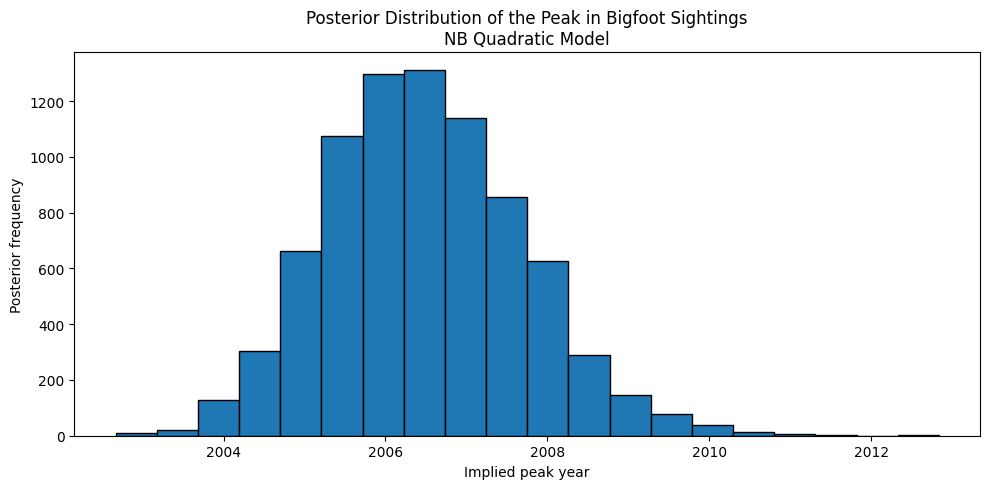

In [ ]:
# ---------------------------------------------------------
# Plot posterior distribution of implied peak year
# ---------------------------------------------------------
peak_years = peak_dates.dt.year + (peak_dates.dt.month - 1) / 12

plt.figure(figsize=(10, 5))
plt.hist(peak_years, bins=20, edgecolor="black")
plt.xlabel("Implied peak year")
plt.ylabel("Posterior frequency")
plt.title("Posterior Distribution of the Peak in Bigfoot Sightings\nNB Quadratic Model")
plt.tight_layout()
plt.show()